# Feature Engineering Demo: Time Series and Spectral Data

This notebook is a workshop demo for feature engineering with ordered signals. It starts with a familiar time-series forecasting example and then reuses the same ideas for spectral data.

The main idea is simple: both time series and spectra are ordered signals. The difference is what the x-axis means.

- In time series, the x-axis is time.
- In spectra such as NIRS, the x-axis is wavelength.

We will use scikit-learn baselines throughout. For later deep-learning examples in this bootcamp, prefer PyTorch.

In [39]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

warnings.filterwarnings('ignore')
np.random.seed(42)

print('NumPy version:', np.__version__)
print('pandas version:', pd.__version__)

NumPy version: 2.4.3
pandas version: 3.0.2


## 1. Start with a time series forecasting problem

We begin with a simple synthetic monthly time series. This is easier to reason about because we are mostly familiar with the idea of using earlier months to predict a later month.

The aim is not to build the best forecaster. The aim is to make the input and output structure completely clear before we move to spectral data.

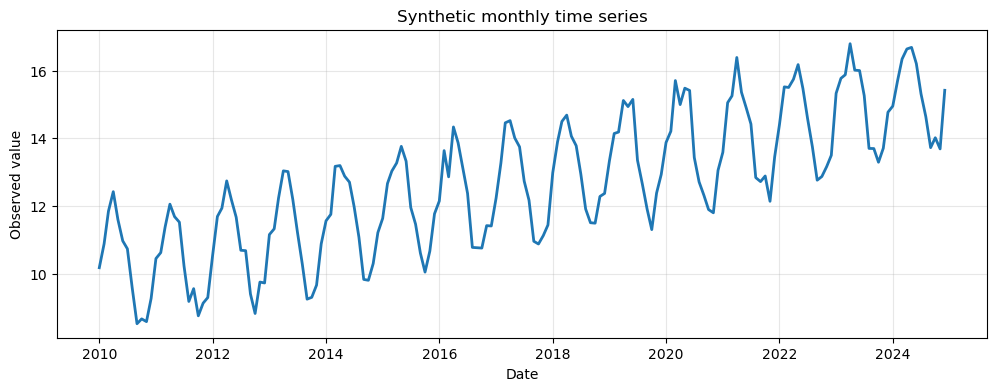

2010-01-01    10.173850
2010-02-01    10.881607
2010-03-01    11.845537
2010-04-01    12.423060
2010-05-01    11.596892
Freq: MS, Name: value, dtype: float64

In [38]:
n_points = 180
dates = pd.date_range('2010-01-01', periods=n_points, freq='MS')
time_index = np.arange(n_points)
trend = 10 + 0.03 * time_index
seasonality = 1.8 * np.sin(2 * np.pi * time_index / 12)
noise = np.random.normal(0, 0.35, n_points)
ts_series = pd.Series(trend + seasonality + noise, index=dates, name='value')

plt.figure(figsize=(12, 4))
plt.plot(ts_series.index, ts_series.values, linewidth=2)
plt.title('Synthetic monthly time series')
plt.xlabel('Date')
plt.ylabel('Observed value')
plt.grid(True, alpha=0.3)
plt.show()

display(ts_series.head())

## 2. Turn the time series into a supervised learning table

This is the key step. We convert one ordered series into rows of features and targets.

- **Input X** will contain lagged features such as the value 1, 3, 6, and 12 months ago.
- **Output y** will be the value we want to predict for the current month.

So each row asks: given some earlier observations, can we predict the next one?

In [40]:
def make_lagged_table(series, lags=(1, 3, 6, 12), rolling_window=3):
    df = pd.DataFrame({'target': series})
    for lag in lags:
        df[f'lag_{lag}'] = series.shift(lag)
    df[f'rolling_mean_{rolling_window}'] = series.shift(1).rolling(rolling_window).mean()
    df['month'] = series.index.month
    return df.dropna()

lagged_df = make_lagged_table(ts_series)
feature_cols = ['lag_1', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'month']
X_time = lagged_df[feature_cols]
y_time = lagged_df['target']

print('Time-series input table X shape:', X_time.shape)
print('Time-series output y shape:', y_time.shape)
print('Feature columns:', feature_cols)
print('\nFirst few supervised rows:')
display(lagged_df.head())

Time-series input table X shape: (168, 6)
Time-series output y shape: (168,)
Feature columns: ['lag_1', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'month']

First few supervised rows:


,target,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,month
2011-01-01,10.444687,9.266995,8.659896,10.732724,10.173850,8.835283,1
2011-02-01,10.620352,10.444687,8.578958,9.578602,10.881607,9.430213,2
2011-03-01,11.375124,10.620352,9.266995,8.516838,11.845537,10.110678,3
2011-04-01,12.053199,11.375124,10.444687,8.659896,12.423060,10.813388,4
2011-05-01,11.684355,12.053199,10.620352,8.578958,11.596892,11.349559,5


Linear regression RMSE: 0.451
Linear regression MAE: 0.385
Naive last-value RMSE: 0.758


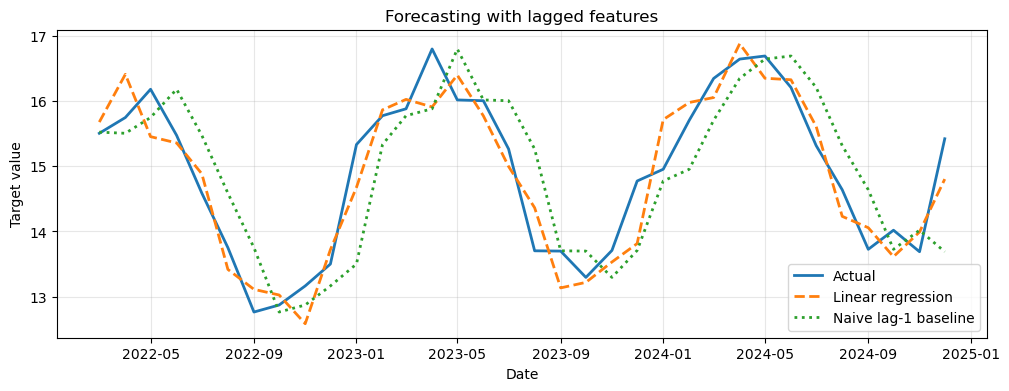

In [41]:
split_index = int(len(lagged_df) * 0.8)
X_train_time = X_time.iloc[:split_index]
X_test_time = X_time.iloc[split_index:]
y_train_time = y_time.iloc[:split_index]
y_test_time = y_time.iloc[split_index:]

time_model = LinearRegression()
time_model.fit(X_train_time, y_train_time)
time_predictions = time_model.predict(X_test_time)
naive_predictions = X_test_time['lag_1'].to_numpy()

time_rmse = mean_squared_error(y_test_time, time_predictions) ** 0.5
time_mae = mean_absolute_error(y_test_time, time_predictions)
naive_rmse = mean_squared_error(y_test_time, naive_predictions) ** 0.5

print('Linear regression RMSE:', round(time_rmse, 3))
print('Linear regression MAE:', round(time_mae, 3))
print('Naive last-value RMSE:', round(naive_rmse, 3))

plt.figure(figsize=(12, 4))
plt.plot(y_test_time.index, y_test_time.values, label='Actual', linewidth=2)
plt.plot(y_test_time.index, time_predictions, label='Linear regression', linestyle='--', linewidth=2)
plt.plot(y_test_time.index, naive_predictions, label='Naive lag-1 baseline', linestyle=':', linewidth=2)
plt.title('Forecasting with lagged features')
plt.xlabel('Date')
plt.ylabel('Target value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Preprocessing an ordered signal

Before moving to spectra, it helps to see that ordered data can also be smoothed or transformed. These ideas will later transfer directly to NIRS.

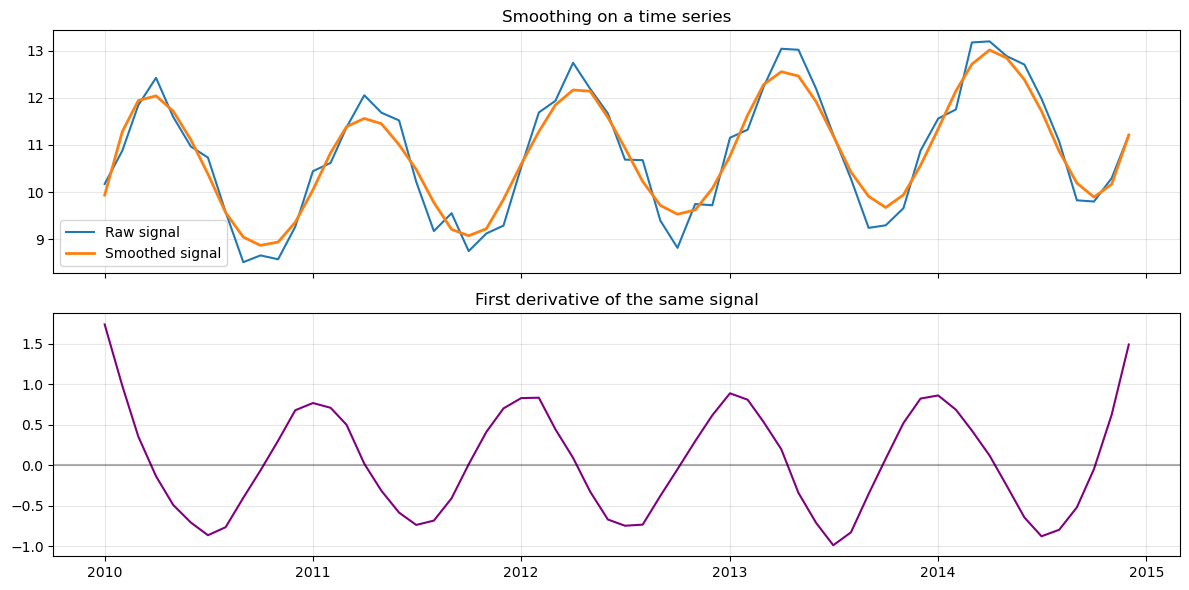

In [27]:
def smooth_1d(signal, window=11, order=3):
    return savgol_filter(signal, window_length=window, polyorder=order)

def derivative_1d(signal, window=11, order=3):
    return savgol_filter(signal, window_length=window, polyorder=order, deriv=1)

example_signal = ts_series.iloc[:60].to_numpy()
example_dates = ts_series.index[:60]
smoothed_signal = smooth_1d(example_signal)
signal_derivative = derivative_1d(example_signal)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(example_dates, example_signal, label='Raw signal')
axes[0].plot(example_dates, smoothed_signal, label='Smoothed signal', linewidth=2)
axes[0].set_title('Smoothing on a time series')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(example_dates, signal_derivative, color='purple')
axes[1].axhline(0, color='black', alpha=0.3)
axes[1].set_title('First derivative of the same signal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Now transfer the same idea to spectral and related signal data

A spectrum is also an ordered signal, but now the x-axis is wavelength, frequency, or another ordered measurement axis. The supervised learning structure is still the same:

- **Input X**: one signal or spectrum per sample, often represented by many ordered measurements or by engineered features
- **Output y**: one target value per sample, such as protein content, class label, concentration, or physiological state

So the structure changes from forecasting across time to predicting a sample-level target from an ordered profile.

### Other data types where similar feature engineering ideas can help

You do not need to analyse all of these in the same way. The point is just to notice that similar feature-engineering thinking can be useful across many kinds of ordered data.

Examples include:

- **NIRS** spectra
- **mass spectrometry** data
- **hyperspectral imaging** data
- **EEG** recordings
- **MEG** recordings

In each case, you may still think about ideas such as smoothing, local patterns, peak-like behaviour, summary statistics, band-based summaries, or window-based features, even though the scientific meaning of the signal is different.

### A note on the spectral data used here

The spectra in this notebook are **artificially generated teaching data**. They are useful for showing the workflow, but they are not intended to reproduce the full messiness of a real experiment.

Real spectral datasets often include more instrument noise, baseline drift, sample-to-sample scatter effects, overlapping peaks, and occasional artefacts. We therefore add some noise and nuisance variation below so the example looks less idealised, while still remaining simple enough for teaching.

In [32]:
def generate_nirs_data(n_samples=220, n_wavelengths=500, seed=42):
    rng = np.random.default_rng(seed)
    wavelengths = np.linspace(1000, 2500, n_wavelengths)

    # Build a few broad absorption patterns that roughly mimic different chemical contributions.
    protein_peak = np.exp(-((wavelengths - 1500) ** 2) / (2 * 100 ** 2))
    protein_peak += 0.5 * np.exp(-((wavelengths - 2050) ** 2) / (2 * 80 ** 2))

    fiber_peak = 0.8 * np.exp(-((wavelengths - 1700) ** 2) / (2 * 120 ** 2))
    fiber_peak += 0.6 * np.exp(-((wavelengths - 2300) ** 2) / (2 * 100 ** 2))

    moisture_peak = 0.4 * np.exp(-((wavelengths - 1450) ** 2) / (2 * 50 ** 2))
    moisture_peak += 0.3 * np.exp(-((wavelengths - 1940) ** 2) / (2 * 60 ** 2))

    # Start from a gently curved baseline rather than a perfectly flat background.
    base = 0.55 + 0.18 * np.sin(wavelengths / 520)

    spectra = []
    protein_targets = []

    for _ in range(n_samples):
        # These hidden values define the sample-level target and some nuisance variation.
        protein = rng.uniform(0.5, 2.0)
        fiber = rng.uniform(0.3, 1.5)
        moisture = rng.uniform(0.2, 0.8)

        # Multiplicative scatter and baseline drift are common in real spectra.
        scale = rng.uniform(0.9, 1.1)
        baseline_shift = rng.uniform(-0.08, 0.08)
        linear_drift = rng.uniform(-0.00015, 0.00015) * (wavelengths - wavelengths.mean())

        spectrum = base.copy()
        spectrum += protein * protein_peak
        spectrum += fiber * fiber_peak
        spectrum += moisture * moisture_peak

        # Add a weak nuisance bump so samples are not explained only by the main peaks.
        nuisance_center = rng.uniform(1200, 2400)
        nuisance_width = rng.uniform(40, 140)
        nuisance_height = rng.uniform(-0.08, 0.12)
        spectrum += nuisance_height * np.exp(-((wavelengths - nuisance_center) ** 2) / (2 * nuisance_width ** 2))

        # Apply scatter and baseline effects.
        spectrum = scale * spectrum + baseline_shift + linear_drift

        # Add stronger measurement noise so the example looks less idealised.
        spectrum += rng.normal(0, 0.05, n_wavelengths)

        spectra.append(spectrum)
        protein_targets.append(protein)

    return np.array(spectra), np.array(protein_targets), wavelengths

X_nirs, y_protein, wavelengths = generate_nirs_data()
print('Spectral input X shape:', X_nirs.shape)
print('Regression target y shape:', y_protein.shape)
print('Interpretation: rows are samples, columns are wavelength measurements, y is one protein value per sample.')

Spectral input X shape: (220, 500)
Regression target y shape: (220,)
Interpretation: rows are samples, columns are wavelength measurements, y is one protein value per sample.


The generation cell above is deliberately more verbose than strictly necessary because the code is part of the teaching material.

The important ideas are:

- each row in `X_nirs` is one artificial spectrum
- `y_protein` is the sample-level regression target we want to predict
- the spectra include both signal and nuisance variation
- the nuisance variation is there to make the example less unrealistically clean

In a real dataset, you would not know the hidden generative process. You would only observe the spectra and the measured target values.

## 5. Spectral feature engineering is analogous to the lagged-feature table

In the time-series example, we summarised earlier time points with lags and rolling means.

For spectra, we can create an analogous feature table using:

- average absorbance in wavelength bands
- peak location and peak size
- derivative summaries that capture local change

Again, the result is a normal tabular `X` matrix plus a target vector `y`.

In [33]:
def create_spectral_features(spectra, wavelengths):
    derivative = np.gradient(spectra, axis=1)
    peak_index = np.argmax(spectra, axis=1)

    features = pd.DataFrame({
        'signal_mean': spectra.mean(axis=1),
        'signal_std': spectra.std(axis=1),
        'signal_range': spectra.max(axis=1) - spectra.min(axis=1),
        'peak_wavelength': wavelengths[peak_index],
        'peak_value': spectra.max(axis=1),
        'derivative_mean': derivative.mean(axis=1),
        'derivative_std': derivative.std(axis=1),
        'derivative_abs_mean': np.abs(derivative).mean(axis=1),
    })

    band_edges = [(1000, 1400), (1400, 1700), (1700, 2100), (2100, 2500)]
    for start, end in band_edges:
        mask = (wavelengths >= start) & (wavelengths < end)
        features[f'band_mean_{start}_{end}'] = spectra[:, mask].mean(axis=1)
        features[f'band_std_{start}_{end}'] = spectra[:, mask].std(axis=1)

    return features

X_nirs_smoothed = np.apply_along_axis(smooth_1d, 1, X_nirs)
spectral_features_raw = create_spectral_features(X_nirs, wavelengths)
spectral_features_smooth = create_spectral_features(X_nirs_smoothed, wavelengths)

print('Raw spectral feature table shape:', spectral_features_raw.shape)
print('Smoothed spectral feature table shape:', spectral_features_smooth.shape)
display(spectral_features_raw.head())

Raw spectral feature table shape: (220, 16)
Smoothed spectral feature table shape: (220, 16)


,signal_mean,signal_std,signal_range,peak_wavelength,peak_value,derivative_mean,derivative_std,derivative_abs_mean,band_mean_1000_1400,band_std_1000_1400,band_mean_1400_1700,band_std_1400_1700,band_mean_1700_2100,band_std_1700_2100,band_mean_2100_2500,band_std_2100_2500
0,1.138467,0.578513,2.307757,1502.004008,2.672710,-0.000094,0.037850,0.029768,0.754128,0.310523,2.135094,0.381738,1.116771,0.168453,0.810575,0.157038
1,1.152046,0.556157,2.273835,1508.016032,2.550157,-0.000890,0.038437,0.030484,0.837297,0.259011,2.135991,0.265761,1.097742,0.219107,0.797317,0.200485
2,0.927007,0.311414,1.449988,1502.004008,1.750318,-0.000486,0.036403,0.029078,0.778394,0.139680,1.463954,0.156260,0.921241,0.112152,0.686187,0.133330
3,0.885264,0.265335,1.148359,1483.967936,1.513183,-0.000594,0.035476,0.028233,0.728947,0.108537,1.325451,0.080715,0.886056,0.179954,0.717256,0.131664
4,0.976781,0.488566,2.045267,1505.010020,2.320365,-0.000586,0.039062,0.030933,0.811086,0.241665,1.801142,0.376970,0.916910,0.152623,0.594804,0.152761


,version,rmse,mae,r2
1,smoothed spectra features,0.101,0.085,0.931
0,raw spectra features,0.102,0.085,0.929


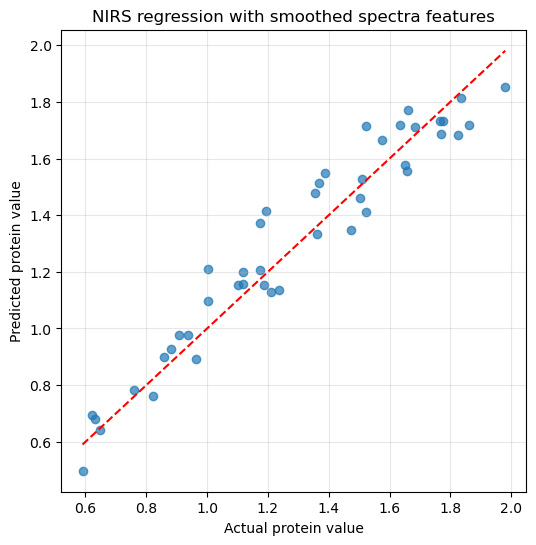

In [34]:
def evaluate_regression_feature_table(features, target, label):
    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    return {
        'label': label,
        'rmse': mean_squared_error(y_test, predictions) ** 0.5,
        'mae': mean_absolute_error(y_test, predictions),
        'r2': r2_score(y_test, predictions),
        'y_test': y_test,
        'predictions': predictions,
    }

raw_result = evaluate_regression_feature_table(spectral_features_raw, y_protein, 'raw spectra features')
smooth_result = evaluate_regression_feature_table(spectral_features_smooth, y_protein, 'smoothed spectra features')
results_df = pd.DataFrame([
    {'version': raw_result['label'], 'rmse': raw_result['rmse'], 'mae': raw_result['mae'], 'r2': raw_result['r2']},
    {'version': smooth_result['label'], 'rmse': smooth_result['rmse'], 'mae': smooth_result['mae'], 'r2': smooth_result['r2']},
]).sort_values('rmse')
display(results_df.round(3))

best_result = raw_result if raw_result['rmse'] <= smooth_result['rmse'] else smooth_result
plt.figure(figsize=(6, 6))
plt.scatter(best_result['y_test'], best_result['predictions'], alpha=0.7)
plt.plot([best_result['y_test'].min(), best_result['y_test'].max()], [best_result['y_test'].min(), best_result['y_test'].max()], linestyle='--', color='red')
plt.xlabel('Actual protein value')
plt.ylabel('Predicted protein value')
plt.title(f'NIRS regression with {best_result["label"]}')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Visualise the spectral input and the regression target

This makes the supervised structure concrete. The left plot shows examples of the spectral **inputs**. The right plot shows the distribution of the regression **output** we are trying to predict.

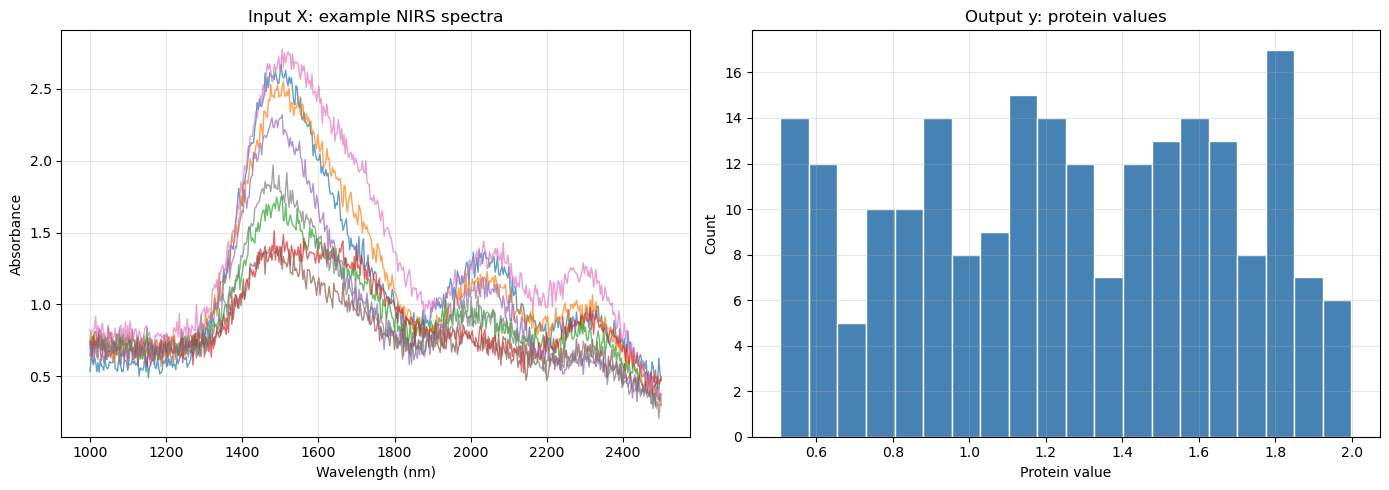

Mean 5-fold CV RMSE for raw spectral feature table: 0.086


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i in range(8):
    axes[0].plot(wavelengths, X_nirs[i], alpha=0.7, linewidth=1)
axes[0].set_title('Input X: example NIRS spectra')
axes[0].set_xlabel('Wavelength (nm)')
axes[0].set_ylabel('Absorbance')
axes[0].grid(True, alpha=0.3)

axes[1].hist(y_protein, bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Output y: protein values')
axes[1].set_xlabel('Protein value')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

cv_rmse = -cross_val_score(LinearRegression(), spectral_features_raw, y_protein, cv=5, scoring='neg_root_mean_squared_error').mean()
print('Mean 5-fold CV RMSE for raw spectral feature table:', round(cv_rmse, 3))

## 7. Takeaways

- Start with the familiar case: earlier time points predict later time points.
- Once the `X` and `y` structure is clear, spectra are easier to explain as the same idea over wavelength.
- Lag features in time series and band-summary features in spectra play similar roles.
- A simple sklearn regression baseline is often enough to teach the core feature-engineering idea before moving to PyTorch models later.

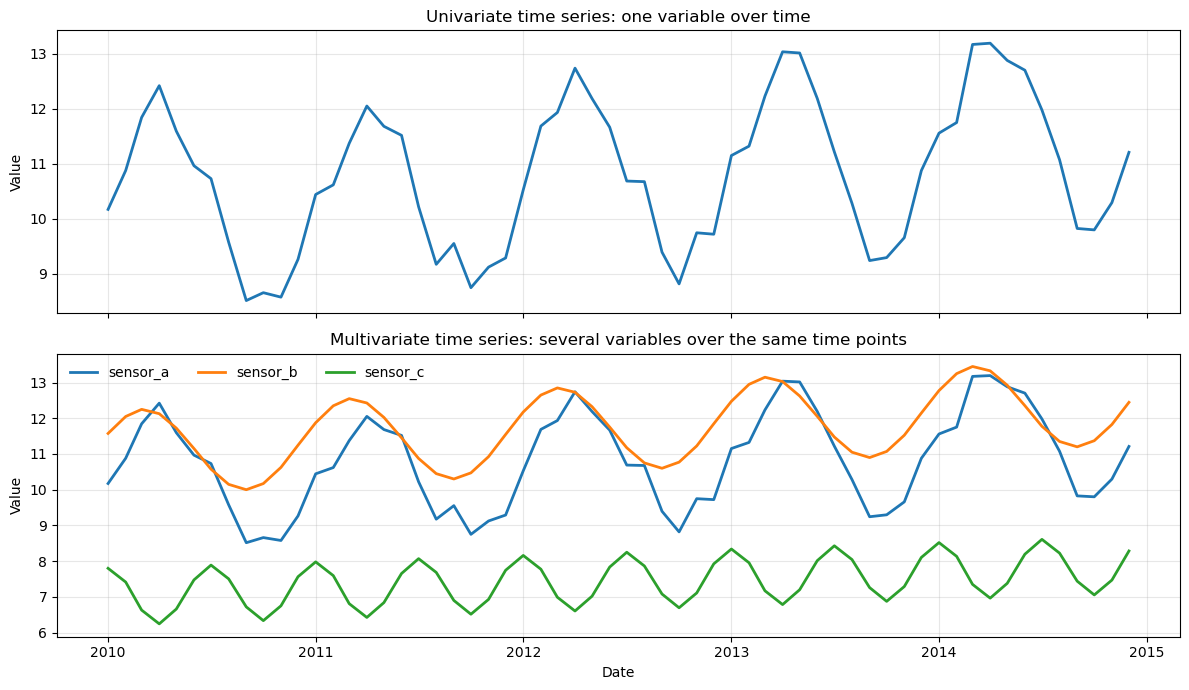

Saved figure to AAISS25_html/docs/fig/time_series_univariate_multivariate.png


In [36]:
from pathlib import Path

fig_path = Path("AAISS25_html/docs/fig/time_series_univariate_multivariate.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)

example_dates = ts_series.index[:60]
example_univariate = ts_series.iloc[:60]
example_time = np.arange(len(example_dates))

multivariate_df = pd.DataFrame(
    {
        "sensor_a": example_univariate.to_numpy(),
        "sensor_b": 11 + 0.025 * example_time + 1.2 * np.sin(2 * np.pi * example_time / 12 + 0.5),
        "sensor_c": 7 + 0.015 * example_time + 0.8 * np.cos(2 * np.pi * example_time / 6),
    },
    index=example_dates,
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(example_univariate.index, example_univariate.values, color="tab:blue", linewidth=2)
axes[0].set_title("Univariate time series: one variable over time")
axes[0].set_ylabel("Value")
axes[0].grid(True, alpha=0.3)

for column in multivariate_df.columns:
    axes[1].plot(multivariate_df.index, multivariate_df[column], linewidth=2, label=column)
axes[1].set_title("Multivariate time series: several variables over the same time points")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Value")
axes[1].legend(ncol=3, frameon=False)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved figure to {fig_path}")